<a href="https://colab.research.google.com/github/boshun/investing/blob/main/%E8%82%A1%E5%B8%82%E5%8D%B0%E9%88%94%E6%A9%9F_TW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ 系統啟動時間: 2026-01-12 04:37

🔍 正在分析大盤趨勢 (使用 0050.TW 代表)...


/tmp/ipython-input-3836220255.py:84: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(etf.iloc[-1])
/tmp/ipython-input-3836220255.py:85: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ma60 = float(etf.rolling(60).mean().iloc[-1])


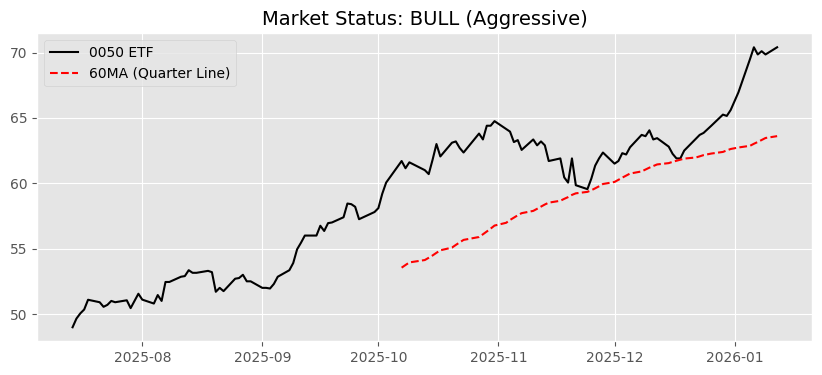

   - 0050 收盤價: 70.40
   - 60日生命線: 63.60
🚀 判定結果：【攻擊模式 (AGGRESSIVE)】
👉 策略重心：追逐動能強勢股 (60%)、輕價值 (20%)

📥 正在掃描 198 檔成分股 (請耐心等候 1-2 分鐘)...

🏆 本月量化選股 Top 10 名單 (模式: AGGRESSIVE)
📅 建議執行日期: 2026-01-12
       代號  收盤價  總分  平均漲幅      平均年線乖離 平均波動率
0   2408.TW  236.00  2.50  +450.04%  -2.386 (正=便宜)      0.045
1   2344.TW  102.00  2.15  +418.99%  -2.536 (正=便宜)      0.048
2  8299.TWO 1760.00  0.92  +221.22%  -2.078 (正=便宜)      0.043
3   6770.TW   49.90  0.76  +173.97%  -0.964 (正=便宜)      0.039
4  8358.TWO  258.00  0.60  +208.91%  -1.657 (正=便宜)      0.039
5  5289.TWO  633.00  0.54  +153.61%  -1.342 (正=便宜)      0.035
6   2451.TW  239.00  0.46  +145.07%  -1.473 (正=便宜)      0.041
7  3260.TWO  272.50  0.42  +172.88%  -1.642 (正=便宜)      0.042
8   1303.TW   64.20  0.39   +96.98%  -0.415 (正=便宜)      0.038
9   2368.TW  671.00  0.37  +133.68%  -1.652 (正=便宜)      0.035

💡 操作建議 (SOP)：
1. 【資金分配】：建議資金等分 10 份，以「市價單」或「收盤價」買進上述 10 檔。
2. 【停損設定】：
   👉 當前為攻擊模式，波動較大。建議單一個股跌幅 > 15% 時停損出場。
3. 【下次換股】：請於下個月的今天，再次執行本程式。


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# 設定顯示格式
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.unicode.east_asian_width', True)
plt.style.use('ggplot')

print(f"✅ 系統啟動時間: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

# ==============================================================================
# 1. 定義全台股明星池 (Universe)
# ==============================================================================
def get_universe():
    # 包含 TW50, 中型100, 富櫃50 成分股 (約 110 檔)
    # Updated '上市權值' (TWSE listed) stocks based on user provided data.
    twse_tickers = [
        '2330.TW', '2317.TW', '2454.TW', '2308.TW', '3711.TW', '2891.TW', '2881.TW',
        '2382.TW', '2882.TW', '2303.TW', '2345.TW', '2412.TW', '2884.TW', '2886.TW',
        '2887.TW', '3231.TW', '2885.TW', '3017.TW', '2383.TW', '6669.TW', '2327.TW',
        '1216.TW', '2357.TW', '2360.TW', '2890.TW', '2892.TW', '2301.TW', '1303.TW',
        '2880.TW', '3661.TW', '2883.TW', '3665.TW', '5880.TW', '2379.TW', '2408.TW',
        '3008.TW', '3034.TW', '2002.TW', '3653.TW', '2603.TW', '2059.TW', '1301.TW',
        '4904.TW', '2207.TW', '3045.TW', '6919.TW', '2395.TW', '2912.TW', '2615.TW',
        '6505.TW',
        '1101.TW', '1102.TW', '1216.TW', '1229.TW', '1301.TW', '1303.TW', '1319.TW',
        '1326.TW', '1402.TW', '1476.TW', '1477.TW', '1503.TW', '1504.TW', '1513.TW',
        '1519.TW', '1590.TW', '1605.TW', '1722.TW', '1795.TW', '1802.TW', '2002.TW',
        '2006.TW', '2027.TW', '2049.TW', '2059.TW', '2105.TW', '2206.TW', '2207.TW',
        '2301.TW', '2303.TW', '2308.TW', '2313.TW', '2317.TW', '2324.TW', '2327.TW',
        '2330.TW', '2344.TW', '2345.TW', '2347.TW', '2353.TW', '2354.TW', '2356.TW',
        '2357.TW', '2360.TW', '2368.TW', '2371.TW', '2376.TW', '2377.TW', '2379.TW',
        '2382.TW', '2383.TW', '2385.TW', '2395.TW', '2404.TW', '2408.TW', '2409.TW',
        '2412.TW', '2449.TW', '2451.TW', '2454.TW', '2474.TW', '2539.TW', '2542.TW',
        '2603.TW', '2609.TW', '2610.TW', '2615.TW', '2618.TW', '2633.TW', '2645.TW',
        '2646.TW', '2801.TW', '2812.TW', '2834.TW', '2845.TW', '2880.TW', '2881.TW',
        '2882.TW', '2883.TW', '2884.TW', '2885.TW', '2886.TW', '2887.TW', '2890.TW',
        '2891.TW', '2892.TW', '2912.TW', '2915.TW', '3005.TW', '3008.TW', '3017.TW',
        '3023.TW', '3034.TW', '3036.TW', '3037.TW', '3044.TW', '3045.TW', '3231.TW',
        '3406.TW', '3443.TW', '3481.TW', '3533.TW', '3653.TW', '3661.TW', '3665.TW',
        '3702.TW', '3706.TW', '3711.TW', '4763.TW', '4904.TW', '4938.TW', '4958.TW',
        '5269.TW', '5434.TW', '5871.TW', '5876.TW', '5880.TW', '6139.TW', '6176.TW',
        '6191.TW', '6239.TW', '6285.TW', '6409.TW', '6415.TW', '6442.TW', '6446.TW',
        '6472.TW', '6505.TW', '6515.TW', '6526.TW', '6531.TW', '6669.TW', '6770.TW',
        '6781.TW', '6789.TW', '6805.TW', '6890.TW', '6919.TW', '7799.TW', '8046.TW',
        '8210.TW', '8454.TW', '8464.TW', '9904.TW', '9910.TW', '9917.TW', '9941.TW',
        '9945.TW'
    ]

    # Original '上櫃熱門' (OTC listed) stocks
    tpex_tickers = [
        '1785.TWO', '1815.TWO', '3078.TWO', '3081.TWO', '3131.TWO', '3211.TWO', '3227.TWO',
        '3260.TWO', '3264.TWO', '3293.TWO', '3324.TWO', '3374.TWO', '3491.TWO', '3529.TWO',
        '3680.TWO', '4749.TWO', '4772.TWO', '4966.TWO', '4979.TWO', '5009.TWO', '5274.TWO',
        '5289.TWO', '5314.TWO', '5347.TWO', '5371.TWO', '5439.TWO', '5483.TWO', '5508.TWO',
        '5536.TWO', '5904.TWO', '6121.TWO', '6146.TWO', '6147.TWO', '6187.TWO', '6188.TWO',
        '6223.TWO', '6274.TWO', '6469.TWO', '6488.TWO', '6510.TWO', '6548.TWO', '6561.TWO',
        '6739.TWO', '7734.TWO', '8069.TWO', '8086.TWO', '8299.TWO', '8358.TWO', '8927.TWO',
        '8932.TWO'
    ]

    tickers = twse_tickers + tpex_tickers
    return list(set(tickers))

# ==============================================================================
# 2. 判斷市場狀態 (Market Regime)
# ==============================================================================
def analyze_market_regime():
    print("\n🔍 正在分析大盤趨勢 (使用 0050.TW 代表)...")
    try:
        # 下載 0050 近半年數據
        etf = yf.download("0050.TW", period="6mo", progress=False, auto_adjust=True)

        # 處理資料格式
        if isinstance(etf.columns, pd.MultiIndex):
            etf = etf['Close']
        else:
            etf = etf['Close'] if 'Close' in etf.columns else etf

        current_price = float(etf.iloc[-1])
        ma60 = float(etf.rolling(60).mean().iloc[-1])

        # 繪製儀表板
        plt.figure(figsize=(10, 4))
        plt.plot(etf.index, etf, label='0050 ETF', color='black')
        plt.plot(etf.index, etf.rolling(60).mean(), label='60MA (Quarter Line)', color='red', linestyle='--')
        plt.title(f"Market Status: {'BULL (Aggressive)' if current_price > ma60 else 'BEAR (Defensive)'}", fontsize=14)
        plt.legend()
        plt.show()

        print(f"   - 0050 收盤價: {current_price:.2f}")
        print(f"   - 60日生命線: {ma60:.2f}")

        if current_price > ma60:
            print("🚀 判定結果：【攻擊模式 (AGGRESSIVE)】")
            print("👉 策略重心：追逐動能強勢股 (60%)、輕價值 (20%)")
            return 'AGGRESSIVE', 0.6, 0.2, 0.2
        else:
            print("🛡️ 判定結果：【防禦模式 (DEFENSIVE)】")
            print("👉 策略重心：尋找低波動避險股 (40%)、重價值 (40%)")
            return 'DEFENSIVE', 0.2, 0.4, 0.4

    except Exception as e:
        print(f"⚠️ 大盤數據讀取失敗: {e}，預設切換為防禦模式。")
        return 'DEFENSIVE', 0.2, 0.4, 0.4

# ==============================================================================
# 3. 核心選股引擎
# ==============================================================================
def run_strategy(mode, w_mom, w_val, w_vol):
    tickers = get_universe()
    print(f"\n📥 正在掃描 {len(tickers)} 檔成分股 (請耐心等候 1-2 分鐘)...")

    # 下載近五年數據 (計算 5年線用)
    data = yf.download(tickers, period="5y", group_by='ticker', progress=False, threads=True, auto_adjust=True)

    results = []

    for ticker in tickers:
        try:
            # 取得個股數據
            if ticker in data.columns.levels[0]:
                df = data[ticker].copy()
            else:
                continue

            df.dropna(inplace=True)
            # 剔除剛上市或數據不足 (需要至少1200個數據點來計算5年線和240日波動/動能)
            if len(df) < 1200: continue

            # 最新收盤價
            price_now = float(df['Close'].iloc[-1])

            # --- 因子計算 ---
            # 1. 動能 (三個月、六個月、一年漲幅)
            mom_3m_raw = (price_now - float(df['Close'].iloc[-60])) / float(df['Close'].iloc[-60])
            mom_6m_raw = (price_now - float(df['Close'].iloc[-120])) / float(df['Close'].iloc[-120])
            mom_1y_raw = (price_now - float(df['Close'].iloc[-240])) / float(df['Close'].iloc[-240])

            # 2. 價值 (年線、二年線、五年線乖離) - (年線 - 股價) / 年線
            ma200 = float(df['Close'].rolling(200).mean().iloc[-1])
            val_1y_raw = (ma200 - price_now) / ma200

            ma480 = float(df['Close'].rolling(480).mean().iloc[-1]) # 約2年
            val_2y_raw = (ma480 - price_now) / ma480

            ma1200 = float(df['Close'].rolling(1200).mean().iloc[-1]) # 約5年
            val_5y_raw = (ma1200 - price_now) / ma1200

            # 3. 波動 (20日、60日、240日振幅)
            vol_20d_raw = float(df['Close'].pct_change().rolling(20).std().iloc[-1])
            vol_60d_raw = float(df['Close'].pct_change().rolling(60).std().iloc[-1])
            vol_240d_raw = float(df['Close'].pct_change().rolling(240).std().iloc[-1])

            results.append({
                'Ticker': ticker,
                'Name': ticker.replace('.TW', '').replace('.TWO', ''),
                'Close': price_now,
                'MA60': float(df['Close'].rolling(60).mean().iloc[-1]),
                'MA200': ma200,

                'Mom_3M_Raw': mom_3m_raw,
                'Mom_6M_Raw': mom_6m_raw,
                'Mom_1Y_Raw': mom_1y_raw,

                'Val_1Y_Raw': val_1y_raw,
                'Val_2Y_Raw': val_2y_raw,
                'Val_5Y_Raw': val_5y_raw,

                'Vol_20D_Raw': vol_20d_raw,
                'Vol_60D_Raw': vol_60d_raw,
                'Vol_240D_Raw': vol_240d_raw
            })
        except Exception as e:
            # print(f"Error processing {ticker}: {e}") # For debugging, uncomment if needed
            continue

    # --- 評分系統 ---
    df_rank = pd.DataFrame(results).dropna() # 剔除數據不足的股票

    # Z-Score 標準化
    def z(s): return (s - s.mean()) / s.std()

    # 計算各子因子Z-Score
    df_rank['Z_Mom_3M'] = z(df_rank['Mom_3M_Raw'])
    df_rank['Z_Mom_6M'] = z(df_rank['Mom_6M_Raw'])
    df_rank['Z_Mom_1Y'] = z(df_rank['Mom_1Y_Raw'])

    df_rank['Z_Val_1Y'] = z(df_rank['Val_1Y_Raw'])
    df_rank['Z_Val_2Y'] = z(df_rank['Val_2Y_Raw'])
    df_rank['Z_Val_5Y'] = z(df_rank['Val_5Y_Raw'])

    df_rank['Z_Vol_20D'] = z(df_rank['Vol_20D_Raw']) * -1 # 波動越小越好，故取負
    df_rank['Z_Vol_60D'] = z(df_rank['Vol_60D_Raw']) * -1
    df_rank['Z_Vol_240D'] = z(df_rank['Vol_240D_Raw']) * -1

    # 計算綜合Z-Score (取平均)
    df_rank['Z_Mom'] = df_rank[['Z_Mom_3M', 'Z_Mom_6M', 'Z_Mom_1Y']].mean(axis=1)
    df_rank['Z_Val'] = df_rank[['Z_Val_1Y', 'Z_Val_2Y', 'Z_Val_5Y']].mean(axis=1)
    df_rank['Z_Vol'] = df_rank[['Z_Vol_20D', 'Z_Vol_60D', 'Z_Vol_240D']].mean(axis=1)

    # 計算綜合原始分數 (供顯示用，取平均)
    df_rank['Mom_Raw'] = df_rank[['Mom_3M_Raw', 'Mom_6M_Raw', 'Mom_1Y_Raw']].mean(axis=1)
    df_rank['Val_Raw'] = df_rank[['Val_1Y_Raw', 'Val_2Y_Raw', 'Val_5Y_Raw']].mean(axis=1)
    df_rank['Vol_Raw'] = df_rank[['Vol_20D_Raw', 'Vol_60D_Raw', 'Vol_240D_Raw']].mean(axis=1)

    # 加權總分
    df_rank['Score'] = (w_mom * df_rank['Z_Mom']) + (w_val * df_rank['Z_Val']) + (w_vol * df_rank['Z_Vol'])

    # 取前 10 名
    top_10 = df_rank.sort_values(by='Score', ascending=False).head(10).reset_index(drop=True)

    return top_10

# ==============================================================================
# 4. 執行與報告
# ==============================================================================
if __name__ == "__main__":
    # 1. 判斷環境
    mode, w1, w2, w3 = analyze_market_regime()

    # 2. 執行選股
    final_df = run_strategy(mode, w1, w2, w3)

    # 3. 輸出報表
    print("\n" + "="*80)
    print(f"🏆 本月量化選股 Top 10 名單 (模式: {mode})")
    print(f"📅 建議執行日期: {datetime.now().strftime('%Y-%m-%d')}")
    print("="*80)

    if not final_df.empty:
        # 整理欄位
        display_df = final_df[['Ticker', 'Close', 'Score', 'Mom_Raw', 'Val_Raw', 'Vol_Raw']].copy()
        display_df.columns = ['代號', '收盤價', '總分', '平均漲幅', '平均年線乖離', '平均波動率']

        # 格式化
        display_df['平均漲幅'] = display_df['平均漲幅'].apply(lambda x: f"{x*100:+.2f}%")
        display_df['平均年線乖離'] = display_df['平均年線乖離'].apply(lambda x: f"{x:.3f} (正=便宜)")
        display_df['平均波動率'] = display_df['平均波動率'].apply(lambda x: f"{x:.3f}")

        print(display_df)

        print("\n💡 操作建議 (SOP)：")
        print("1. 【資金分配】：建議資金等分 10 份，以「市價單」或「收盤價」買進上述 10 檔。")
        print("2. 【停損設定】：")
        if mode == 'AGGRESSIVE':
            print("   👉 當前為攻擊模式，波動較大。建議單一個股跌幅 > 15% 時停損出場。")
        else:
            print("   👉 當前為防禦模式，強調保本。建議單一個股跌幅 > 10% 時停損出場。")
        print("3. 【下次換股】：請於下個月的今天，再次執行本程式。")

    else:
        print("❌ 錯誤：無法產出選股名單，請檢查網路連線。")